<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/3_EDA_bivariate_multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns


In [8]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
titanic = sns.load_dataset('titanic')
titanic

In [ ]:
flight = sns.load_dataset('flights')
flight

In [ ]:
iris = sns.load_dataset('iris')
iris

# 1.Scatterplot(Numerical - Numerical)


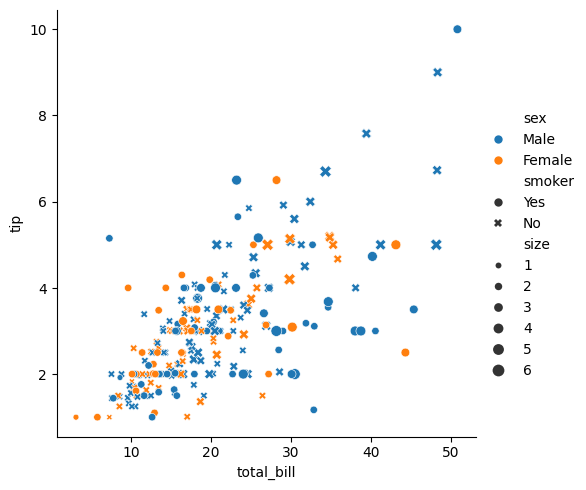

In [12]:
sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter', hue='sex', style='smoker', size='size')

# 2. Bar Plot (Numerical - Categoical)


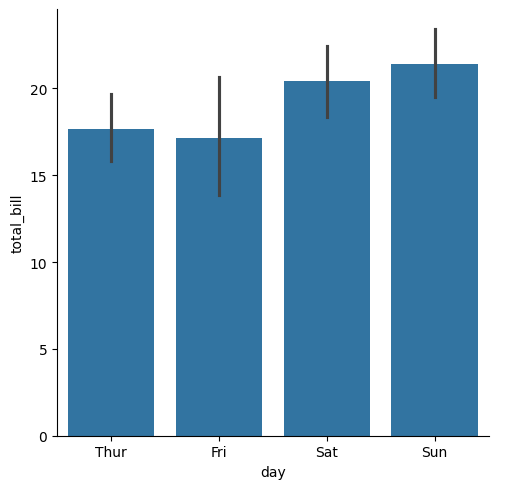

In [20]:
sns.catplot(data=tips, x='day', y='total_bill', kind='bar')

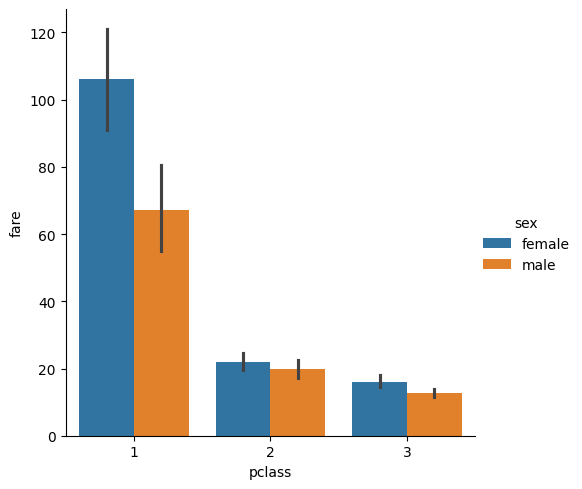

In [28]:
sns.catplot(data=titanic, x='pclass', y='fare', kind='bar', hue='sex')

# 3. Box PLot (Numerical - Categorical)

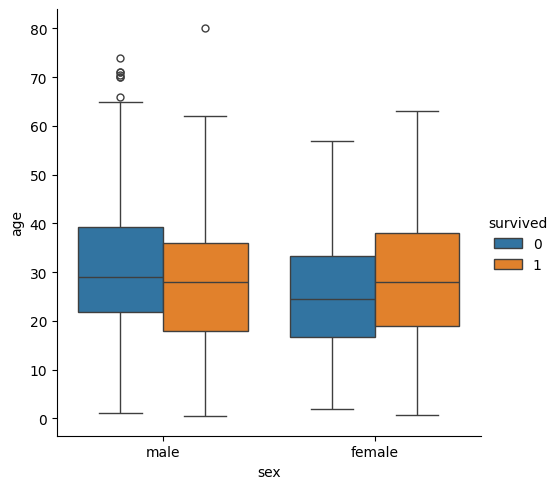

In [30]:
sns.catplot(data=titanic, x='sex', y='age', kind='box', hue='survived')

# 4. Distplot(Numerical - Categorical)

/tmp/ipykernel_1742/4054338558.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['survived']==0]['age'], hist=False)
/tmp/ipykernel_1742/4054338558.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['survived']==1]['age'], hist=False)


<Axes: xlabel='age', ylabel='Density'>

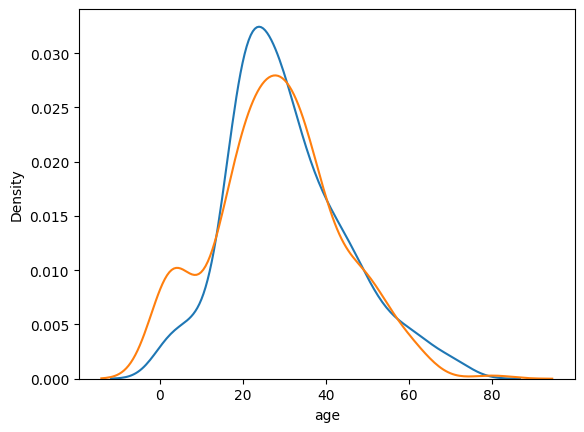

In [36]:
sns.distplot(titanic[titanic['survived']==0]['age'], hist=False)
sns.distplot(titanic[titanic['survived']==1]['age'], hist=False)


# 5. HeatMap(categorical -categorical)

In [37]:
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [38]:
# crosstab
pd.crosstab(titanic['pclass'], titanic['survived'])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


crosstab()

→ pd.crosstab() is used to create a frequency table between two or more categorical variables.
→ It helps analyze the relationship between categories by counting how often each combination occurs.
→ Commonly used in EDA to compare categories such as Gender vs Survival, Department vs Salary, etc.

<Axes: xlabel='survived', ylabel='pclass'>

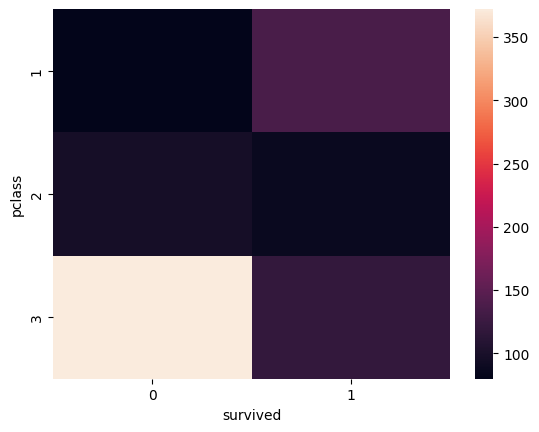

In [39]:
sns.heatmap(pd.crosstab(titanic['pclass'], titanic['survived']))

In [43]:
titanic.groupby('pclass')['survived'].agg('mean')*100


,survived
pclass,
1,62.962963
2,47.282609
3,24.236253


<Axes: xlabel='pclass'>

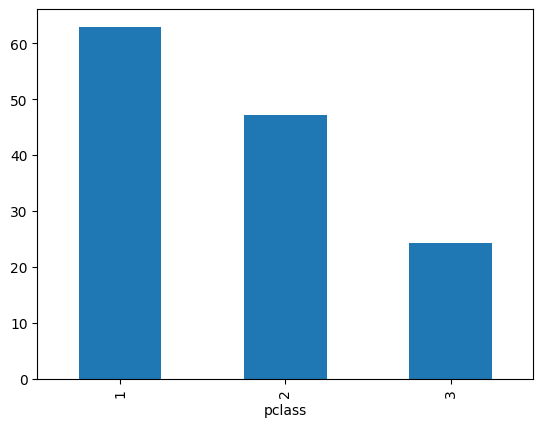

In [44]:
(titanic.groupby('pclass')['survived'].agg('mean')*100).plot(kind='bar')


In [46]:
titanic.groupby('embarked')['survived'].agg('mean')*100

,survived
embarked,
C,55.357143
Q,38.961039
S,33.695652


# 6. ClusterMap (categorical - categoricaal)

In [48]:
pd.crosstab(titanic['sibsp'], titanic['survived'])

survived,0,1
sibsp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


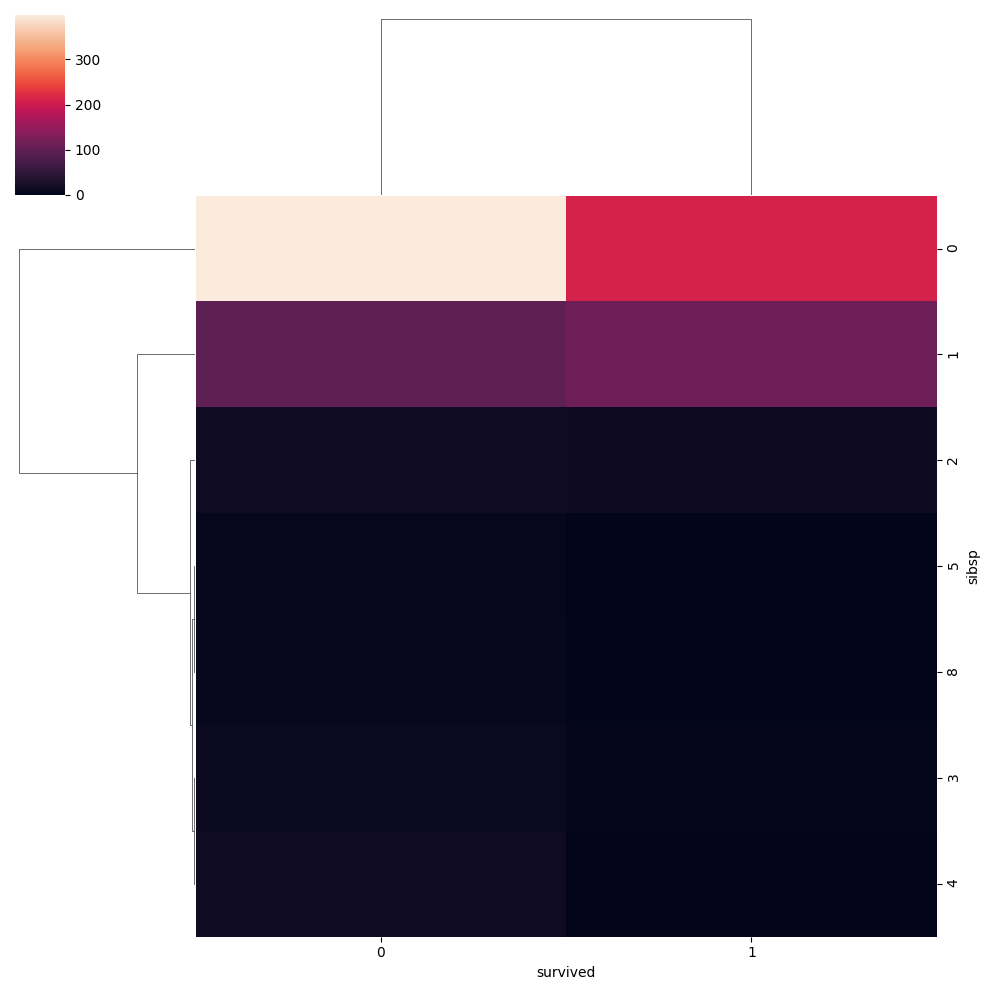

In [49]:
sns.clustermap(pd.crosstab(titanic['sibsp'], titanic['survived']))

# 7. Pairplot

## it automatically detect the numerical column and make the graph

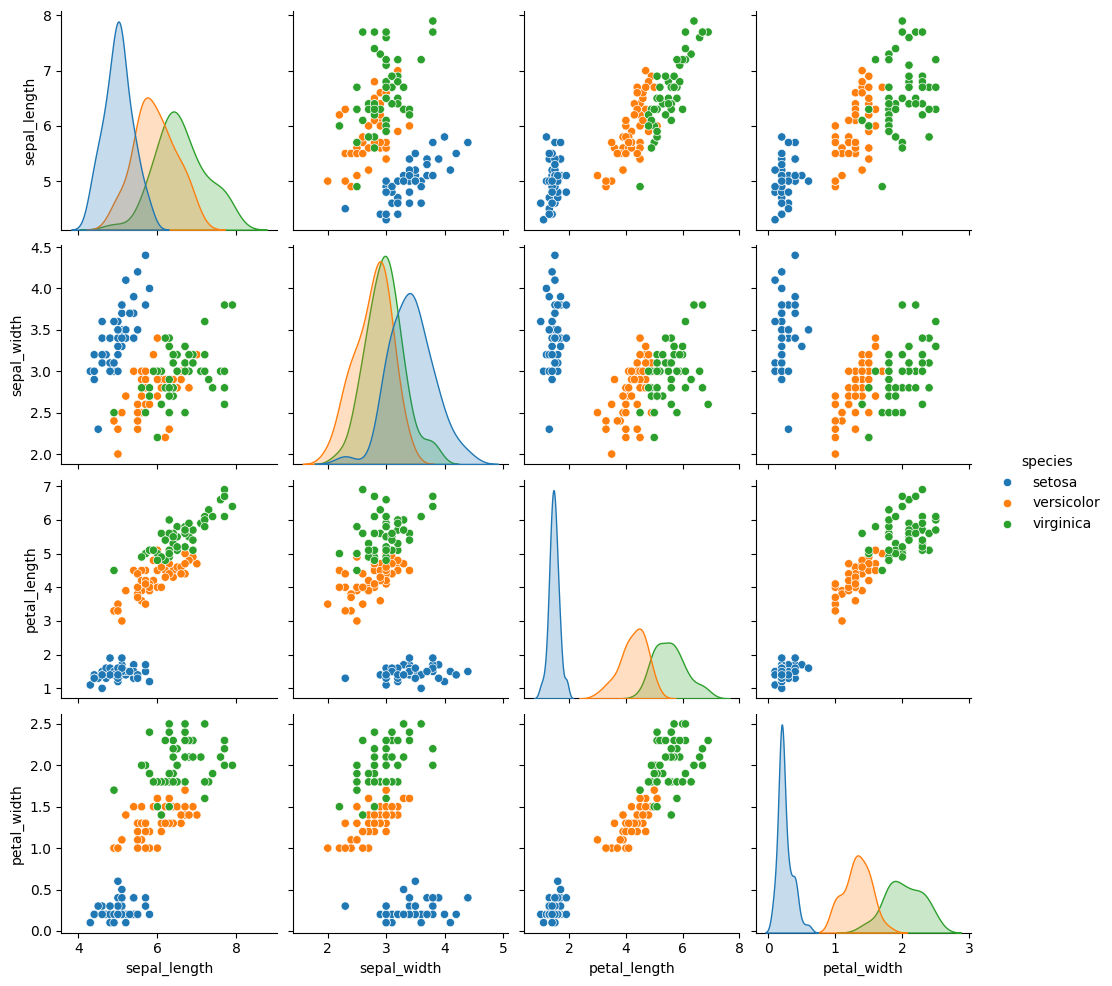

In [51]:
sns.pairplot(iris, hue='species')

# 8. Lineplot(Numerical - Numerical)

In [52]:
flight

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [67]:
new = flight.groupby('year')['passengers'].sum().reset_index()
new

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


<Axes: xlabel='year', ylabel='passengers'>

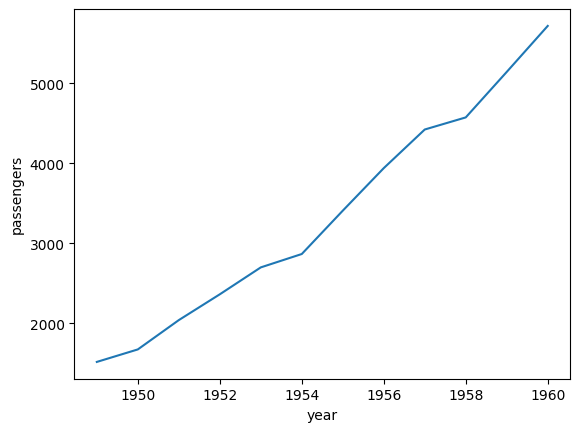

In [69]:
sns.lineplot(data=new, x='year', y='passengers')

In [75]:
heat = pd.pivot(data=flight, columns='year', values='passengers', index='month')
heat

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


<Axes: xlabel='year', ylabel='month'>

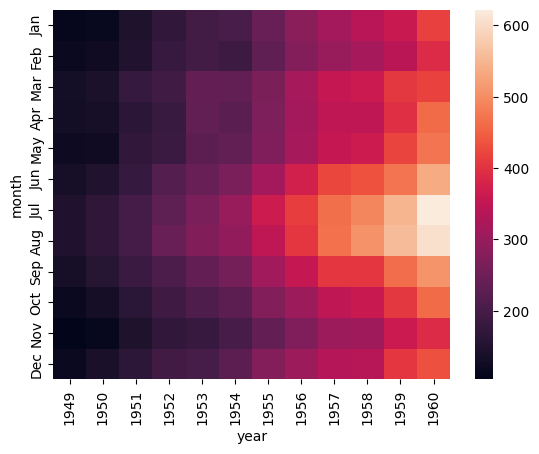

In [76]:
sns.heatmap(heat)

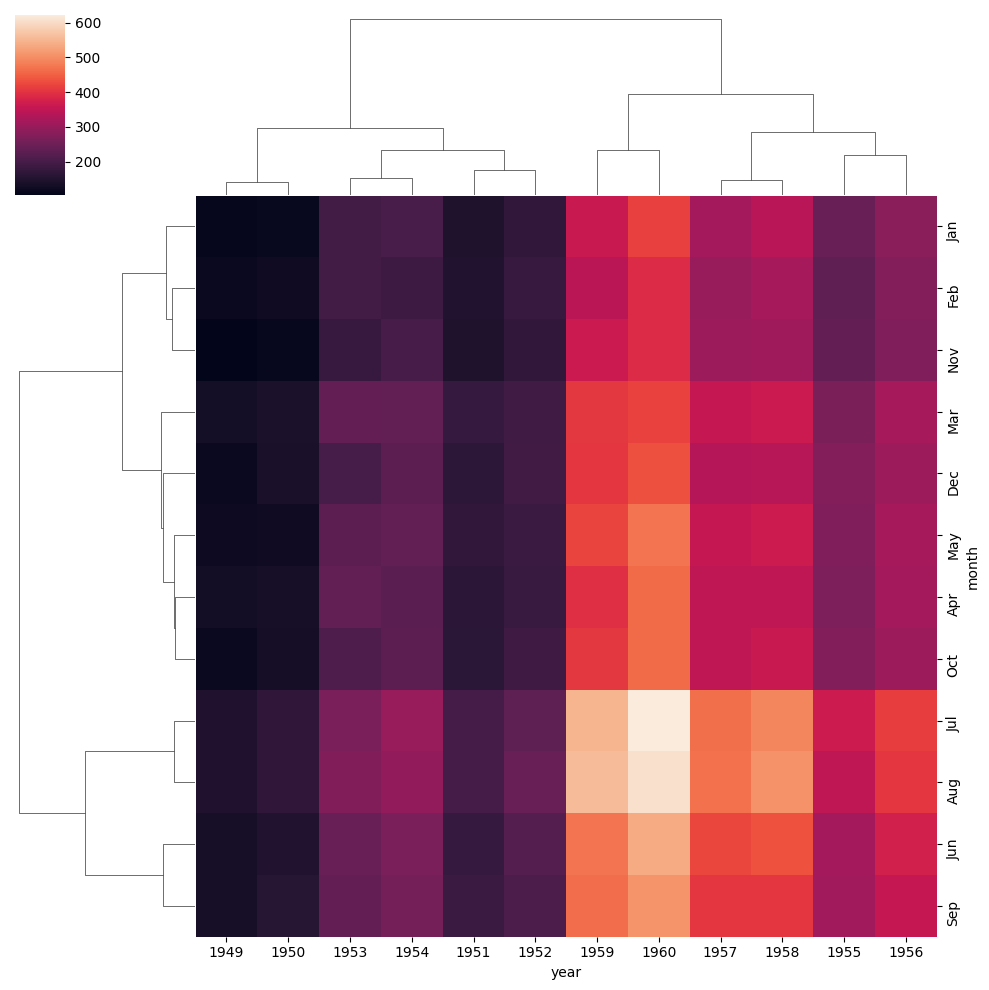

In [77]:
sns.clustermap(heat)